Customer Churn Prediction

 1. Data Loading

Importing Pandas

In [ ]:
import pandas as pd
import numpy as np  

Loading the Dataset

In [2]:
df = pd.read_csv('customer_churn_data.csv')

2. Initial Data Exploration

In [ ]:
# Display First 10 Records
df.head(10)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
5,6,42,Female,16,119.75,Two-Year,DSL,1916.00,Yes,Yes
6,7,60,Male,14,80.32,One-Year,,1124.48,No,Yes
7,8,52,Female,6,58.90,One-Year,,353.40,No,Yes
8,9,40,Female,53,49.81,Two-Year,Fiber Optic,2639.93,Yes,No
9,10,50,Female,10,61.55,Month-to-Month,Fiber Optic,615.50,Yes,Yes


Dataset Info Summary

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  1000 non-null   object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


Check for Missing Values

In [109]:
df.isna().sum() # Check for missing values in each column

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

3. Data Cleaning

Fill Missing InternetService Values

In [110]:
df["InternetService"] = df["InternetService"].fillna("")  # Fill missing values in 'InternetService' with ''

Confirm All Missing Values Are Handled

In [111]:
df.isna().sum().sum()  # Check if there are any missing values left 

np.int64(0)

Data Preview

In [173]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [174]:
df.duplicated().sum()  # Check for duplicate rows  

np.int64(0)

In [234]:
# Data preview
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [293]:
# Descriptive Statistics
df.describe()   

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [294]:
# Select Numeric Columns
numeric_columns_data = df.select_dtypes(include=['number'])
numeric_columns_data

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [ ]:
# Correlation Matrix
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


4. Data Visualization

In [ ]:
# Import Matplotlib and Seaborn
import matplotlib.pyplot as plt
import seaborn as sns   

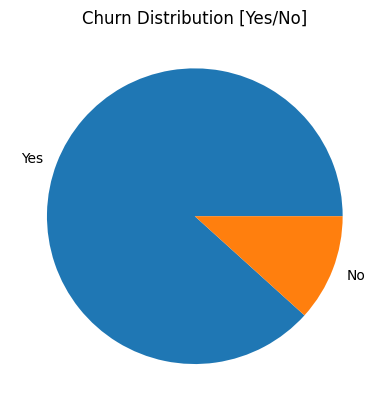

In [ ]:
# Churn Distribution Pie Chart
df["Churn"].value_counts().plot(kind="pie")  # Check the distribution of the target variable
plt.title("Churn Distribution [Yes/No]")
plt.ylabel("")  
plt.show()              

In [ ]:
# Data Preview
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [ ]:
# Monthly Charges by Churn
df.groupby("Churn")["MonthlyCharges"].mean() # Compare average monthly charges for churned vs non-churned customers

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [ ]:
# Monthly Charges by Gender & Churn      
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()  

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [ ]:
# Average Tenure by Churn
df.groupby("Churn")["Tenure"].mean() 

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [ ]:
# Display First 2 Records
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [ ]:
# Average Age by Churn
df.groupby("Churn")["Age"].mean()  

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

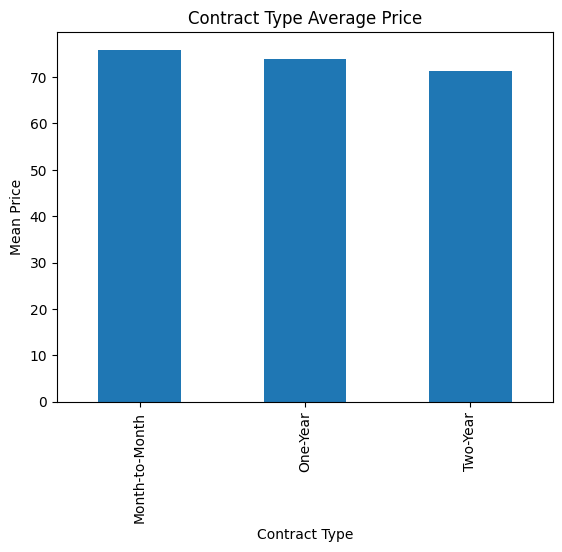

In [ ]:
# Bar Plot of Monthly Charges by Contract Type
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")  # Check churn distribution by contract type
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

In [ ]:
# Display First 2 Records
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


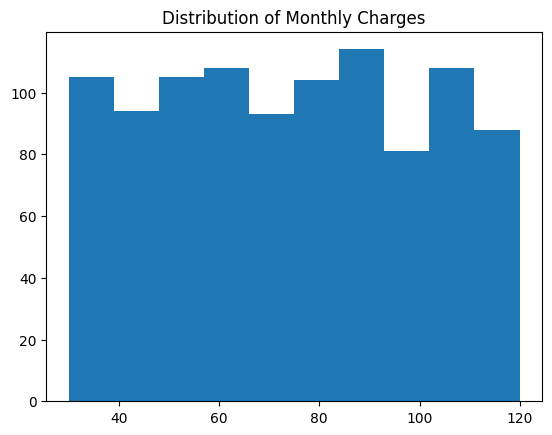

In [ ]:
# Visualize the distribution of monthly charges
plt.hist(df["MonthlyCharges"])  # Visualize the distribution of monthly charges
plt.title("Distribution of Monthly Charges")
plt.show("Monthly Charges")

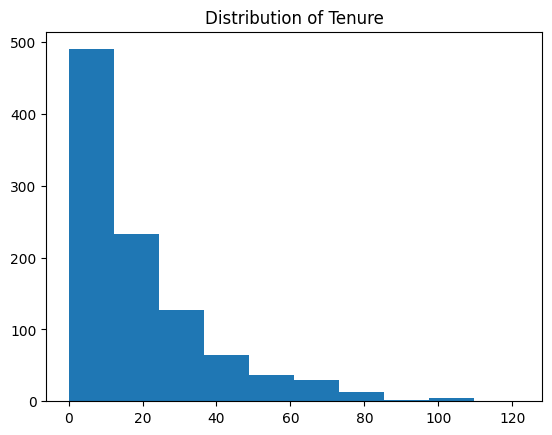

In [ ]:
# Histogram of Tenure
plt.hist(df["Tenure"])  # Visualize the distribution of tenure
plt.title("Distribution of Tenure") 
plt.show("Tenure")

5. Feature Engineering

In [ ]:
# Display DataFrame Columns
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [ ]:
# Display First Record
df.head(1) 

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [ ]:
# Define Features and Target
y = df[["Churn"]]  # Target variable
X = df[["Age","Gender","Tenure","MonthlyCharges"]]  # Features	

In [253]:
X # 1-Female 0 Male

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [ ]:
# Encode Gender Column
X["Gender"] = X["Gender"].apply(lambda x: 1 if x =="Female" else 0)  # Convert

In [ ]:
# Preview Encoded Features
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [ ]:
# Check Data Type of Encoded Gender
type(X["Gender"][0])  # Check the data type of the

numpy.int64

In [ ]:
# Convert target variable to binary
y["Churn"] = y["Churn"]. apply(lambda x: 1 if x == "Yes" else 0)  # Convert target variable to binary

In [ ]:
# Check Data Type of Encoded Churn
type(y["Churn"][0])

numpy.int64

In [ ]:
# Display the first few records of the features and target variable
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


6. Train-Test for Model Evaluation

In [ ]:
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [261]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [ ]:
# Import StandardScaler from sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit and transform the training data

In [ ]:
# Transform the test data
import joblib
joblib.dump(scaler, 'scaler.pkl')  # Save the scaler for future use 

['scaler.pkl']

a. Logistic Regression

In [ ]:
# Transform the test data using the fitted scaler
X_test = scaler.fit_transform(X_test)  # Transform the test data using the fitted scaler

In [ ]:
# Import LogisticRegression from sklearn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))
    

In [ ]:
# Import warnings to ignore warnings
import warnings
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

# Import GridSearchCV from sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [ ]:
# Initialize and fit the logistic regression model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)  # Fit the model on the training data

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [268]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [269]:
y_pred = log_model.predict(X_test)  # Predict churn for a sample input

In [270]:
modelperformance(y_pred)  # Evaluate the model performance  

Accuracy score on model is 0.845


b.  KNeighborsClassifier

In [271]:
from sklearn.neighbors import KNeighborsClassifier

In [272]:
param_grid = {
    "n_neighbors" : [3, 5, 7, 9],
    "weights" : ["uniform", "distance"],
}

In [273]:
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
gridkn.fit(X_train, y_train)  # Fit the grid search model on the training

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [274]:
gridkn.best_params_  # Get the best parameters from the grid search

{'n_neighbors': 7, 'weights': 'uniform'}

In [275]:
y_pred2 = gridkn.predict(X_test)  # Predict churn using the best parameters   

In [276]:
modelperformance(y_pred2)  # Evaluate the model performance with grid search

Accuracy score on model is 0.845


C. SVM

In [277]:
from sklearn.svm import SVC

In [278]:
SVM = SVC()

In [279]:
param_grid = {
    "C": [0.01, 0.1,0.5,1],     
    "kernel" : ["linear", "rbf", "poly"]
}

In [280]:
gridsvc = GridSearchCV(SVM, param_grid, cv=5)
gridsvc.fit(X_train, y_train)  # Fit the grid search model on the training data         
gridsvc.best_params_  # Get the best parameters from the grid search    

{'C': 0.01, 'kernel': 'linear'}

In [281]:
y_pred3 = gridsvc.predict(X_test)  # Predict churn using the best parameters    
modelperformance(y_pred3)  # Evaluate the model performance with grid search

Accuracy score on model is 0.85


D. Decision tree

In [282]:
from sklearn.tree import DecisionTreeClassifier

In [283]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split" : [2, 5, 10],  
    "min_samples_leaf": [1, 2, 4]
}

In [284]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_tree.fit(X_train, y_train)  # Fit the grid search model on the training data
grid_tree.best_params_  # Get the best parameters from the grid search

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [285]:
y_pred4 = grid_tree.predict(X_test)  # Predict churn using the best parameters
modelperformance(y_pred4)  # Evaluate the model performance with grid search

Accuracy score on model is 0.84


E. Random Forest

In [286]:
from sklearn.ensemble import RandomForestClassifier         
rfc_model = RandomForestClassifier()   

In [287]:
param_grid = {  
    "n_estimators": [32,64, 128,256],
    "max_features": [2, 3, 4],
    "bootstrap": [True, False]
}   

In [288]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)
grid_rfc.fit(X_train, y_train)  # Fit the grid search model on the
grid_rfc.best_params_  # Get the best parameters from the grid search   

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64}

In [289]:
y_pred5 = grid_tree.predict(X_test)  # Predict churn using the best parameters
modelperformance(y_pred5)  # Evaluate the model performance with grid search

Accuracy score on model is 0.84


In [290]:
best_model = gridsvc.best_estimator_

In [291]:
joblib.dump(best_model, 'model.pkl')  # Save the best model for future use

['model.pkl']

In [292]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')